# Phase 7-A — Real Observation Consistency Study

## Goal

This notebook starts the bridge from the synthetic black-hole memory experiments to real observational imagery.

The purpose is **not** to claim that real EHT images have known accretion histories. They do not.

Instead, Phase 7-A asks a safer and more defensible question:

> Do real or externally supplied black-hole observations occupy the same morphology / latent-feature space as the synthetic memory datasets?

This is a **real-observation consistency study**, not a supervised real-history prediction study.

## What this notebook does

1. Loads synthetic reference datasets from the previous project phases.
2. Loads real or external observation images from a user-provided folder.
3. Computes morphology statistics for both synthetic and real images.
4. Extracts latent features using a trained Phase 2 / Phase 2.2 U-Net encoder if available.
5. Reduces feature space with PCA.
6. Compares synthetic and real samples in morphology and latent space.
7. Finds nearest synthetic analogues for each real observation.
8. Generates a thesis-style Phase 7-A summary.

## Required input folder

Put real/external images here:

```text
/home/marwa/files/phase1_blackhole_generator/data/real_observations
```

Supported formats:

```text
.png, .jpg, .jpeg, .tif, .tiff
```

If no real images are found, the notebook will still run the synthetic audit and tell you what to add.

In [1]:
# ================================================================
# 1. Imports and setup
# ================================================================

import os
import json
import math
import random
import hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    from sklearn.neighbors import NearestNeighbors
    from sklearn.metrics import pairwise_distances
    SKLEARN_AVAILABLE = True
except Exception as e:
    SKLEARN_AVAILABLE = False
    print("scikit-learn unavailable:", e)

try:
    from scipy.stats import wasserstein_distance
    SCIPY_AVAILABLE = True
except Exception as e:
    SCIPY_AVAILABLE = False
    print("scipy unavailable:", e)

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("sklearn available:", SKLEARN_AVAILABLE)
print("scipy available:", SCIPY_AVAILABLE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

PyTorch: 2.9.0+cu128
CUDA available: True
sklearn available: True
scipy available: True


device(type='cuda')

In [2]:
# ================================================================
# 2. Configuration
# ================================================================

PROJECT_ROOT = Path("/home/marwa/files/phase1_blackhole_generator")
DATA_ROOT = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

# Real/external observation folder.
# Add real EHT images, externally reconstructed images, or published observation-like images here.
REAL_OBS_DIR = DATA_ROOT / "real_observations"
GRMHD_DIR = DATA_ROOT / "grmhd_simulations"

# Phase 7-A outputs
PHASE7A_DIR = OUTPUT_DIR / "phase7A_real_observation_consistency"
PHASE7A_TABLE_DIR = PHASE7A_DIR / "tables"
PHASE7A_FIG_DIR = PHASE7A_DIR / "figures"
PHASE7A_REPORT_DIR = PHASE7A_DIR / "reports"

for d in [PHASE7A_DIR, PHASE7A_TABLE_DIR, PHASE7A_FIG_DIR, PHASE7A_REPORT_DIR, REAL_OBS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Synthetic reference datasets.
# These are treated as morphology/latent reference domains.
SYNTHETIC_DATASETS = [
    {
        "name": "phase1_original",
        "path": DATA_ROOT / "dataset",
        "description": "Original synthetic black-hole dataset",
    },
    {
        "name": "phase5_coupled",
        "path": DATA_ROOT / "dataset_phase5_coupled",
        "description": "Strongly coupled physical-memory morphology dataset",
    },
    {
        "name": "phase5_8_morphology",
        "path": DATA_ROOT / "dataset_phase5_8_morphology",
        "description": "Morphology-focused synthetic dataset",
    },
    {
        "name": "phase6_memory",
        "path": DATA_ROOT / "dataset_phase6_memory_persistence",
        "description": "Memory-persistence event dataset",
    },
]

# Choose which synthetic split to use as image reference.
# "clean" is preferred for morphology comparison; "noisy" tests observation-corrupted similarity.
SYNTHETIC_IMAGE_MODE = "clean"  # options: "clean", "noisy"

# Real image preprocessing
IMAGE_SIZE = 128
REAL_IMAGE_CROP_TO_SQUARE = True
REAL_IMAGE_INVERT_IF_DARK_RING = False
REAL_IMAGE_NORMALIZE_PERCENTILES = (1, 99)

# Limit synthetic samples for fast analysis.
# Set to None to use all images.
MAX_SYNTHETIC_PER_DATASET = 500

# Analysis settings
SEED = 42
BATCH_SIZE = 32
NUM_WORKERS = 0
N_NEIGHBORS = 5
PCA_COMPONENTS = 10

# U-Net checkpoint candidates.
# The notebook will use the first existing checkpoint.
UNET_CANDIDATES = [
    OUTPUT_DIR / "best_unet_memory_preserving_phase57.pt",
    OUTPUT_DIR / "best_unet_memory_preserving_phase58.pt",
    OUTPUT_DIR / "best_unet_physics_aware_phase5.pt",
    OUTPUT_DIR / "best_unet_physics_aware.pt",
    OUTPUT_DIR / "phase2_2_memory_preserving_reconstruction" / "best_phase2_2_memory_preserving_unet.pt",
]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Project root:", PROJECT_ROOT)
print("Real observations:", REAL_OBS_DIR)
print("Phase 7-A outputs:", PHASE7A_DIR)
print("Synthetic image mode:", SYNTHETIC_IMAGE_MODE)

Project root: /home/marwa/files/phase1_blackhole_generator
Real observations: /home/marwa/files/phase1_blackhole_generator/data/real_observations
Phase 7-A outputs: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency
Synthetic image mode: clean


In [3]:
# ================================================================
# 3. Utility functions
# ================================================================

def file_sha256(path):
    path = Path(path)
    if not path.exists() or not path.is_file():
        return None
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def read_json_if_exists(path):
    path = Path(path)
    if not path.exists():
        return None
    with open(path, "r") as f:
        return json.load(f)

def read_csv_if_exists(path):
    path = Path(path)
    if not path.exists():
        return None
    return pd.read_csv(path)

def save_dataframe(df, name, index=False):
    csv_path = PHASE7A_TABLE_DIR / f"{name}.csv"
    df.to_csv(csv_path, index=index)
    return csv_path

def save_plot(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    return path

def load_image01(path, size=128, crop_to_square=True, normalize_percentiles=None):
    img = Image.open(path).convert("L")

    if crop_to_square:
        img = ImageOps.fit(
            img,
            (min(img.size), min(img.size)),
            method=Image.Resampling.LANCZOS,
            centering=(0.5, 0.5),
        )

    img = img.resize((size, size), Image.Resampling.LANCZOS)
    arr = np.asarray(img, dtype=np.float32) / 255.0

    if normalize_percentiles is not None:
        lo, hi = np.percentile(arr, normalize_percentiles)
        if hi > lo:
            arr = (arr - lo) / (hi - lo)
            arr = np.clip(arr, 0.0, 1.0)

    return arr.astype(np.float32)

def image_to_uint8(arr):
    return (np.clip(arr, 0, 1) * 255).astype(np.uint8)

def list_image_files(folder):
    folder = Path(folder)
    exts = ["*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff", "*.bmp"]
    files = []
    for ext in exts:
        files.extend(sorted(folder.glob(ext)))
    return sorted(files)

In [4]:
# ================================================================
# 4. Real Dataset Acquisition and Verification
# ================================================================

from pathlib import Path

# ------------------------------------------------
# Dataset directories
# ------------------------------------------------

REAL_OBS_DIR = DATA_ROOT / "real_observations"

GRMHD_DIR = DATA_ROOT / "grmhd_simulations"

EHT_DIR = REAL_OBS_DIR / "eht"

M87_DIR = EHT_DIR / "m87"

SGRA_DIR = EHT_DIR / "sgrA"

for d in [
    REAL_OBS_DIR,
    GRMHD_DIR,
    EHT_DIR,
    M87_DIR,
    SGRA_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------
# Instructions
# ------------------------------------------------

print("=" * 80)
print("PHASE 7-A DATASET CHECK")
print("=" * 80)

print()
print("Recommended directory structure:")
print()

print(REAL_OBS_DIR)
print(" └── eht/")
print("     ├── m87/")
print("     └── sgrA/")
print()

print(GRMHD_DIR)
print()

print("=" * 80)

# ------------------------------------------------
# Count files
# ------------------------------------------------

image_extensions = [
    "*.png",
    "*.jpg",
    "*.jpeg",
    "*.tif",
    "*.tiff",
]

def count_images(folder):
    count = 0
    for ext in image_extensions:
        count += len(list(folder.glob(ext)))
    return count

m87_count = count_images(M87_DIR)
sgra_count = count_images(SGRA_DIR)
grmhd_count = count_images(GRMHD_DIR)

print("Dataset inventory")
print("-" * 40)

print(f"M87 images      : {m87_count}")
print(f"Sgr A* images   : {sgra_count}")
print(f"GRMHD images    : {grmhd_count}")

total_real = m87_count + sgra_count

print(f"Total EHT images: {total_real}")

# ------------------------------------------------
# Status assessment
# ------------------------------------------------

print()
print("=" * 80)

if total_real == 0 and grmhd_count == 0:

    print("STATUS: No external datasets detected.")
    print()

    print("Recommended next step:")
    print()

    print("1. Download EHT images:")
    print("   - M87* 2019")
    print("   - M87* Polarization 2021")
    print("   - M87* 2024 reconstruction")
    print("   - Sagittarius A* 2022")
    print()

    print("2. Download a GRMHD image library.")
    print()

    print("3. Place images in:")
    print("   ", REAL_OBS_DIR)
    print("   ", GRMHD_DIR)

elif total_real > 0 and grmhd_count == 0:

    print("STATUS: EHT observations detected.")
    print("GRMHD reference dataset missing.")

elif total_real == 0 and grmhd_count > 0:

    print("STATUS: GRMHD dataset detected.")
    print("EHT observations missing.")

else:

    print("STATUS: EHT + GRMHD datasets detected.")
    print("Phase 7-A can run full consistency analysis.")

print("=" * 80)

# ------------------------------------------------
# Preview files
# ------------------------------------------------

def preview(folder, n=5):

    files = []

    for ext in image_extensions:
        files.extend(folder.glob(ext))

    files = sorted(files)

    return [f.name for f in files[:n]]

print()
print("M87 preview:")
print(preview(M87_DIR))

print()
print("Sgr A* preview:")
print(preview(SGRA_DIR))

print()
print("GRMHD preview:")
print(preview(GRMHD_DIR))

PHASE 7-A DATASET CHECK

Recommended directory structure:

/home/marwa/files/phase1_blackhole_generator/data/real_observations
 └── eht/
     ├── m87/
     └── sgrA/

/home/marwa/files/phase1_blackhole_generator/data/grmhd_simulations

Dataset inventory
----------------------------------------
M87 images      : 0
Sgr A* images   : 3
GRMHD images    : 0
Total EHT images: 3

STATUS: EHT observations detected.
GRMHD reference dataset missing.

M87 preview:
[]

Sgr A* preview:
['eht_2022_D02_02_sgra_imaging_pipelines__disk_blur15uas.png', 'eht_2022_D02_02_sgra_imaging_pipelines__ring_blur20uas.png', 'eht_2022_D02_02_sgra_imaging_pipelines__ring_blur25uas.png']

GRMHD preview:
[]


In [5]:
# ================================================================
# 4B. Optional Public EHT Starter Download
# ================================================================

import urllib.request
from pathlib import Path

DOWNLOAD_PUBLIC_EHT_STARTER = False

# Keep this False by default.
# Set to True only if you want the notebook to download a tiny starter set.
#
# This is NOT a full scientific dataset.
# It is only for Phase 7-A sanity checking:
# synthetic morphology space vs famous public EHT images.

EHT_STARTER_SOURCES = [
    {
        "name": "sgrA_nsf_first_image",
        "target_dir": SGRA_DIR,
        "filename": "sgrA_nsf_first_image.jpg",
        "url": "https://nsf-gov-resources.nsf.gov/styles/large/s3/2022-05/EHT_Saggitarius_A_black_hole_image.jpeg",
        "source_note": "NSF public media image of Sagittarius A* from EHT Collaboration.",
    },
]

def download_file(url, output_path, timeout=60):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists():
        print("Already exists:", output_path)
        return True

    try:
        print("Downloading:")
        print(" ", url)
        print("to:")
        print(" ", output_path)

        request = urllib.request.Request(
            url,
            headers={
                "User-Agent": "Mozilla/5.0"
            },
        )

        with urllib.request.urlopen(request, timeout=timeout) as response:
            data = response.read()

        with open(output_path, "wb") as f:
            f.write(data)

        print("Saved:", output_path)
        return True

    except Exception as e:
        print("Download failed:")
        print(" ", url)
        print("Reason:", e)
        return False


download_log = []

if DOWNLOAD_PUBLIC_EHT_STARTER:

    for item in EHT_STARTER_SOURCES:
        output_path = item["target_dir"] / item["filename"]

        ok = download_file(
            item["url"],
            output_path,
        )

        download_log.append({
            "name": item["name"],
            "url": item["url"],
            "output_path": str(output_path),
            "success": ok,
            "source_note": item["source_note"],
        })

else:
    print("DOWNLOAD_PUBLIC_EHT_STARTER=False")
    print("No files downloaded.")
    print()
    print("To enable the small starter download, set:")
    print("DOWNLOAD_PUBLIC_EHT_STARTER = True")

download_log_df = pd.DataFrame(download_log)

download_log_path = PHASE7A_TABLE_DIR / "phase7A_public_eht_download_log.csv"
download_log_df.to_csv(download_log_path, index=False)

print("Saved download log:", download_log_path)

DOWNLOAD_PUBLIC_EHT_STARTER=False
No files downloaded.

To enable the small starter download, set:
DOWNLOAD_PUBLIC_EHT_STARTER = True
Saved download log: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/tables/phase7A_public_eht_download_log.csv


In [6]:
# ================================================================
# 4. Audit available synthetic and real data
# ================================================================

audit_rows = []

for spec in SYNTHETIC_DATASETS:
    dataset_dir = Path(spec["path"])
    manifest = read_json_if_exists(dataset_dir / "manifest.json")
    params = read_csv_if_exists(dataset_dir / "params_table.csv")

    clean_count = len(list((dataset_dir / "clean").glob("*.png"))) if (dataset_dir / "clean").exists() else 0
    noisy_count = len(list((dataset_dir / "noisy").glob("*.png"))) if (dataset_dir / "noisy").exists() else 0

    audit_rows.append({
        "domain": "synthetic",
        "name": spec["name"],
        "path": str(dataset_dir),
        "exists": dataset_dir.exists(),
        "description": spec["description"],
        "manifest_exists": (dataset_dir / "manifest.json").exists(),
        "params_exists": (dataset_dir / "params_table.csv").exists(),
        "n_params": len(params) if params is not None else np.nan,
        "n_manifest": manifest.get("n_samples", np.nan) if manifest else np.nan,
        "clean_images": clean_count,
        "noisy_images": noisy_count,
        "version": manifest.get("version", "") if manifest else "",
    })

real_files = list_image_files(REAL_OBS_DIR)

audit_rows.append({
    "domain": "real_or_external",
    "name": "real_observations",
    "path": str(REAL_OBS_DIR),
    "exists": REAL_OBS_DIR.exists(),
    "description": "User-supplied real or external black-hole observation images",
    "manifest_exists": False,
    "params_exists": False,
    "n_params": np.nan,
    "n_manifest": np.nan,
    "clean_images": len(real_files),
    "noisy_images": np.nan,
    "version": "",
})

audit_df = pd.DataFrame(audit_rows)
display(audit_df)

audit_path = save_dataframe(audit_df, "phase7A_data_audit")
print("Saved:", audit_path)

if len(real_files) == 0:
    print()
    print("No real/external images found yet.")
    print("Add images to:")
    print(" ", REAL_OBS_DIR)
    print()
    print("The notebook will still run synthetic-side cells, but real consistency results require images.")
else:
    print("Real/external images found:", len(real_files))
    for p in real_files[:10]:
        print(" ", p.name)

,domain,name,path,exists,description,manifest_exists,params_exists,n_params,n_manifest,clean_images,noisy_images,version
0,synthetic,phase1_original,/home/marwa/files/phase1_blackhole_generator/d...,True,Original synthetic black-hole dataset,True,True,1000.0,1000.0,1000,1000.0,1.5
1,synthetic,phase5_coupled,/home/marwa/files/phase1_blackhole_generator/d...,True,Strongly coupled physical-memory morphology da...,True,True,1000.0,1000.0,1000,1000.0,5.0
2,synthetic,phase5_8_morphology,/home/marwa/files/phase1_blackhole_generator/d...,True,Morphology-focused synthetic dataset,True,True,1000.0,1000.0,1000,1000.0,5.8
3,synthetic,phase6_memory,/home/marwa/files/phase1_blackhole_generator/d...,True,Memory-persistence event dataset,True,True,1120.0,1120.0,1120,1120.0,6.0
4,real_or_external,real_observations,/home/marwa/files/phase1_blackhole_generator/d...,True,User-supplied real or external black-hole obse...,False,False,NaN,NaN,0,NaN,


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/tables/phase7A_data_audit.csv

No real/external images found yet.
Add images to:
  /home/marwa/files/phase1_blackhole_generator/data/real_observations

The notebook will still run synthetic-side cells, but real consistency results require images.


In [7]:
# ================================================================
# 5. Build synthetic image index
# ================================================================

synthetic_rows = []

for spec in SYNTHETIC_DATASETS:
    dataset_dir = Path(spec["path"])

    if not dataset_dir.exists():
        continue

    params = read_csv_if_exists(dataset_dir / "params_table.csv")
    if params is None:
        params = pd.DataFrame()

    if "sample_id" not in params.columns and len(params) > 0:
        params["sample_id"] = [f"bh_{i:04d}" for i in range(1, len(params) + 1)]

    if SYNTHETIC_IMAGE_MODE == "clean":
        image_dir = dataset_dir / "clean"
        if not image_dir.exists():
            continue
        image_paths = sorted(image_dir.glob("*.png"))
    elif SYNTHETIC_IMAGE_MODE == "noisy":
        image_dir = dataset_dir / "noisy"
        if not image_dir.exists():
            continue
        image_paths = sorted(image_dir.glob("*_noisy.png"))
    else:
        raise ValueError("SYNTHETIC_IMAGE_MODE must be 'clean' or 'noisy'.")

    if MAX_SYNTHETIC_PER_DATASET is not None:
        image_paths = image_paths[:MAX_SYNTHETIC_PER_DATASET]

    for path in image_paths:
        if SYNTHETIC_IMAGE_MODE == "clean":
            sample_id = path.stem
        else:
            sample_id = path.stem.replace("_noisy", "")

        row = {
            "domain": "synthetic",
            "dataset_name": spec["name"],
            "dataset_path": str(dataset_dir),
            "sample_id": sample_id,
            "image_path": str(path),
            "image_mode": SYNTHETIC_IMAGE_MODE,
            "sha256": file_sha256(path),
        }

        if len(params) > 0 and "sample_id" in params.columns:
            match = params[params["sample_id"].astype(str) == str(sample_id)]
            if len(match) > 0:
                for col in match.columns:
                    if col not in row and col != "sample_id":
                        val = match.iloc[0][col]
                        if np.isscalar(val):
                            row[col] = val

        synthetic_rows.append(row)

synthetic_index_df = pd.DataFrame(synthetic_rows)
display(synthetic_index_df.head())
print("Synthetic images indexed:", len(synthetic_index_df))

synthetic_index_path = save_dataframe(synthetic_index_df, "phase7A_synthetic_image_index")
print("Saved:", synthetic_index_path)

,domain,dataset_name,dataset_path,sample_id,image_path,image_mode,sha256,mass,spin,disk_intensity,...,noise_sigma,blur_sigma,accretion,jet_power,disk_luminosity,event_profile_recent,event_age,event_center,event_type,event_type_index
0,synthetic,phase1_original,/home/marwa/files/phase1_blackhole_generator/d...,bh_0001,/home/marwa/files/phase1_blackhole_generator/d...,clean,185a7677ce7a5f0d513a876700294db2d7e019ffd105e8...,1.145614,0.347241,0.7141,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,synthetic,phase1_original,/home/marwa/files/phase1_blackhole_generator/d...,bh_0002,/home/marwa/files/phase1_blackhole_generator/d...,clean,995777e17c31a25b8d34e4bad927eafa9189b34171613b...,1.954073,0.387645,0.7058,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,synthetic,phase1_original,/home/marwa/files/phase1_blackhole_generator/d...,bh_0003,/home/marwa/files/phase1_blackhole_generator/d...,clean,bb4501e24e9bfbb6fde5bb23e59e5b744256782319ae13...,1.322621,0.334173,0.4601,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,synthetic,phase1_original,/home/marwa/files/phase1_blackhole_generator/d...,bh_0004,/home/marwa/files/phase1_blackhole_generator/d...,clean,bfdee2bd92f6ef395e221887e19f75a0a2fa8fa48537e9...,1.120299,0.202217,0.4886,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,synthetic,phase1_original,/home/marwa/files/phase1_blackhole_generator/d...,bh_0005,/home/marwa/files/phase1_blackhole_generator/d...,clean,2a07d056e4ddea54e58f0e9c32164e386e3a74288a7468...,0.855797,0.014027,0.4115,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Synthetic images indexed: 2000
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/tables/phase7A_synthetic_image_index.csv


In [8]:
# ================================================================
# 6. Build real/external observation image index
# ================================================================

real_rows = []

for path in real_files:
    real_rows.append({
        "domain": "real_or_external",
        "dataset_name": "real_observations",
        "sample_id": path.stem,
        "image_path": str(path),
        "image_mode": "external",
        "sha256": file_sha256(path),
    })

real_index_df = pd.DataFrame(real_rows)

if len(real_index_df):
    display(real_index_df)
else:
    print("No real/external images indexed yet.")

real_index_path = save_dataframe(real_index_df, "phase7A_real_image_index")
print("Saved:", real_index_path)

No real/external images indexed yet.
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/tables/phase7A_real_image_index.csv


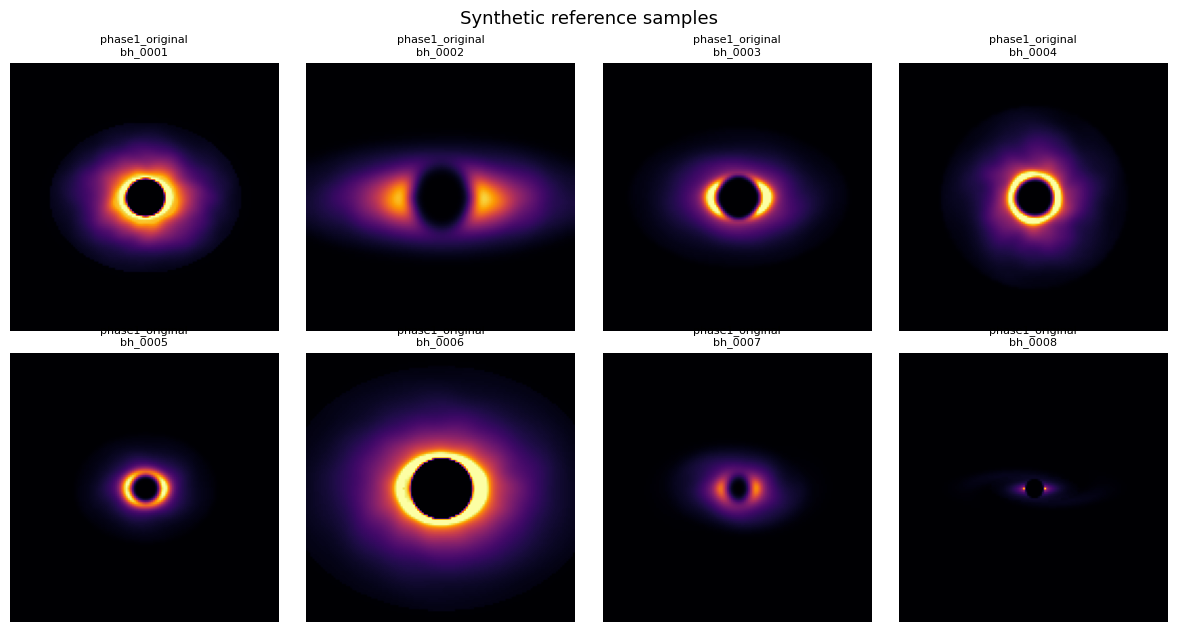

No images to show for: Real / external observation samples


In [9]:
# ================================================================
# 7. Visualize sample images from both domains
# ================================================================

def show_image_grid(index_df, title, n=8):
    if index_df is None or len(index_df) == 0:
        print(f"No images to show for: {title}")
        return

    sample_df = index_df.head(n).copy()
    cols = min(4, len(sample_df))
    rows = int(np.ceil(len(sample_df) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(3.0 * cols, 3.2 * rows), squeeze=False)
    axes = axes.reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        arr = load_image01(
            row["image_path"],
            size=IMAGE_SIZE,
            crop_to_square=True,
            normalize_percentiles=REAL_IMAGE_NORMALIZE_PERCENTILES if row["domain"] != "synthetic" else None,
        )
        ax.imshow(arr, cmap="inferno", vmin=0, vmax=1)
        ax.set_title(f"{row['dataset_name']}\n{row['sample_id']}", fontsize=8)
        ax.axis("off")

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

show_image_grid(synthetic_index_df, "Synthetic reference samples", n=8)
show_image_grid(real_index_df, "Real / external observation samples", n=8)

## Morphology-space consistency

This section computes image statistics that are interpretable without relying on a learned model.

These are not physical measurements; they are controlled morphology descriptors used to compare image domains.

In [10]:
# ================================================================
# 8. Morphology statistics
# ================================================================

def radial_profile_features(image):
    h, w = image.shape
    y, x = np.mgrid[-1:1:complex(h), -1:1:complex(w)]
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)

    center_mask = r < 0.16
    ring_mask = (r >= 0.16) & (r <= 0.42)
    disk_mask = (r > 0.22) & (r < 0.82)
    outer_mask = r >= 0.82

    left_mask = (x < -0.05) & disk_mask
    right_mask = (x > 0.05) & disk_mask
    upper_mask = (y < -0.05) & disk_mask
    lower_mask = (y > 0.05) & disk_mask

    jet_axis_mask = (np.abs(x) < 0.10) & (np.abs(y) > 0.20)
    disk_axis_mask = (np.abs(y) < 0.13) & (np.abs(x) > 0.18)

    eps = 1e-8

    # Weighted centroid
    weight = image + eps
    cx = float((x * weight).sum() / weight.sum())
    cy = float((y * weight).sum() / weight.sum())

    # Brightness-weighted radial statistics
    r_mean = float((r * weight).sum() / weight.sum())
    r_std = float(np.sqrt((((r - r_mean) ** 2) * weight).sum() / weight.sum()))

    # Simple angular asymmetry
    right_mean = float(image[right_mask].mean()) if right_mask.any() else np.nan
    left_mean = float(image[left_mask].mean()) if left_mask.any() else np.nan
    upper_mean = float(image[upper_mask].mean()) if upper_mask.any() else np.nan
    lower_mean = float(image[lower_mask].mean()) if lower_mask.any() else np.nan

    features = {
        "mean_brightness": float(image.mean()),
        "max_brightness": float(image.max()),
        "std_brightness": float(image.std()),
        "p95_brightness": float(np.percentile(image, 95)),
        "p99_brightness": float(np.percentile(image, 99)),
        "center_mean": float(image[center_mask].mean()) if center_mask.any() else np.nan,
        "ring_mean": float(image[ring_mask].mean()) if ring_mask.any() else np.nan,
        "disk_mean": float(image[disk_mask].mean()) if disk_mask.any() else np.nan,
        "outer_mean": float(image[outer_mask].mean()) if outer_mask.any() else np.nan,
        "ring_to_center_ratio": float((image[ring_mask].mean() + eps) / (image[center_mask].mean() + eps)) if ring_mask.any() and center_mask.any() else np.nan,
        "ring_to_outer_ratio": float((image[ring_mask].mean() + eps) / (image[outer_mask].mean() + eps)) if ring_mask.any() and outer_mask.any() else np.nan,
        "texture_std_disk": float(image[disk_mask].std()) if disk_mask.any() else np.nan,
        "centroid_x": cx,
        "centroid_y": cy,
        "radial_mean": r_mean,
        "radial_std": r_std,
        "left_right_asymmetry": float((right_mean - left_mean) / (right_mean + left_mean + eps)),
        "upper_lower_asymmetry": float((lower_mean - upper_mean) / (lower_mean + upper_mean + eps)),
        "jet_axis_mean": float(image[jet_axis_mask].mean()) if jet_axis_mask.any() else np.nan,
        "disk_axis_mean": float(image[disk_axis_mask].mean()) if disk_axis_mask.any() else np.nan,
        "jet_to_disk_axis_ratio": float((image[jet_axis_mask].mean() + eps) / (image[disk_axis_mask].mean() + eps)) if jet_axis_mask.any() and disk_axis_mask.any() else np.nan,
    }

    return features

def compute_morphology_table(index_df, real_preprocess=False):
    rows = []
    for _, row in index_df.iterrows():
        arr = load_image01(
            row["image_path"],
            size=IMAGE_SIZE,
            crop_to_square=True,
            normalize_percentiles=REAL_IMAGE_NORMALIZE_PERCENTILES if real_preprocess else None,
        )

        if real_preprocess and REAL_IMAGE_INVERT_IF_DARK_RING:
            arr = 1.0 - arr

        feats = radial_profile_features(arr)
        base = {
            "domain": row["domain"],
            "dataset_name": row["dataset_name"],
            "sample_id": row["sample_id"],
            "image_path": row["image_path"],
            "image_mode": row["image_mode"],
        }
        base.update(feats)
        rows.append(base)
    return pd.DataFrame(rows)

synthetic_morph_df = compute_morphology_table(synthetic_index_df, real_preprocess=False)

if len(real_index_df):
    real_morph_df = compute_morphology_table(real_index_df, real_preprocess=True)
else:
    real_morph_df = pd.DataFrame()

morphology_df = pd.concat([synthetic_morph_df, real_morph_df], ignore_index=True)

display(morphology_df.head())
print("Morphology rows:", len(morphology_df))

morph_path = save_dataframe(morphology_df, "phase7A_morphology_features")
print("Saved:", morph_path)

,domain,dataset_name,sample_id,image_path,image_mode,mean_brightness,max_brightness,std_brightness,p95_brightness,p99_brightness,...,texture_std_disk,centroid_x,centroid_y,radial_mean,radial_std,left_right_asymmetry,upper_lower_asymmetry,jet_axis_mean,disk_axis_mean,jet_to_disk_axis_ratio
0,synthetic,phase1_original,bh_0001,/home/marwa/files/phase1_blackhole_generator/d...,clean,0.074095,1.000000,0.173381,0.447059,0.890196,...,0.161430,0.012796,0.015171,0.327308,0.132205,0.060027,0.079365,0.106706,0.200557,0.532046
1,synthetic,phase1_original,bh_0002,/home/marwa/files/phase1_blackhole_generator/d...,clean,0.074897,0.894118,0.145455,0.396078,0.717647,...,0.185185,0.019003,0.019137,0.482904,0.191503,0.031878,0.108850,0.033039,0.354056,0.093315
2,synthetic,phase1_original,bh_0003,/home/marwa/files/phase1_blackhole_generator/d...,clean,0.046456,1.000000,0.123775,0.247059,0.718314,...,0.115613,0.015664,0.016138,0.331716,0.142697,0.075091,0.102831,0.046918,0.171943,0.272868
3,synthetic,phase1_original,bh_0004,/home/marwa/files/phase1_blackhole_generator/d...,clean,0.063740,1.000000,0.150418,0.325490,0.953608,...,0.112172,0.009175,0.008895,0.329894,0.145266,0.049839,0.039782,0.108635,0.131814,0.824149
4,synthetic,phase1_original,bh_0005,/home/marwa/files/phase1_blackhole_generator/d...,clean,0.023601,1.000000,0.096843,0.117647,0.600667,...,0.037402,0.008207,0.007873,0.212835,0.095208,0.054098,0.070615,0.016843,0.047225,0.356650


Morphology rows: 2000
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/tables/phase7A_morphology_features.csv


,dataset_name,domain,n,mean_brightness_mean,mean_brightness_std,std_brightness_mean,std_brightness_std,p95_brightness_mean,p95_brightness_std,center_mean_mean,...,left_right_asymmetry_mean,left_right_asymmetry_std,upper_lower_asymmetry_mean,upper_lower_asymmetry_std,jet_axis_mean_mean,jet_axis_mean_std,disk_axis_mean_mean,disk_axis_mean_std,jet_to_disk_axis_ratio_mean,jet_to_disk_axis_ratio_std
0,phase1_original,synthetic,500,0.078781,0.065285,0.150816,0.065736,0.388609,0.258947,0.209115,...,0.028126,0.045252,0.082752,0.045629,0.109559,0.118160,0.203073,0.134010,0.478999,0.327251
1,phase5_8_morphology,synthetic,500,0.094078,0.058298,0.172402,0.047005,0.448063,0.242805,0.217574,...,0.030900,0.069883,0.107729,0.067350,0.160751,0.109878,0.224561,0.112646,0.745821,0.370491
2,phase5_coupled,synthetic,500,0.082386,0.054008,0.144277,0.046978,0.366083,0.184836,0.181483,...,0.022886,0.080576,0.107227,0.077448,0.141445,0.097534,0.192452,0.106048,0.814274,0.445666
3,phase6_memory,synthetic,500,0.070428,0.029270,0.116880,0.027797,0.285294,0.082214,0.255588,...,-0.001424,0.024522,0.009034,0.011857,0.110900,0.054806,0.148305,0.037657,0.716099,0.256015


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/tables/phase7A_morphology_summary_by_dataset.csv


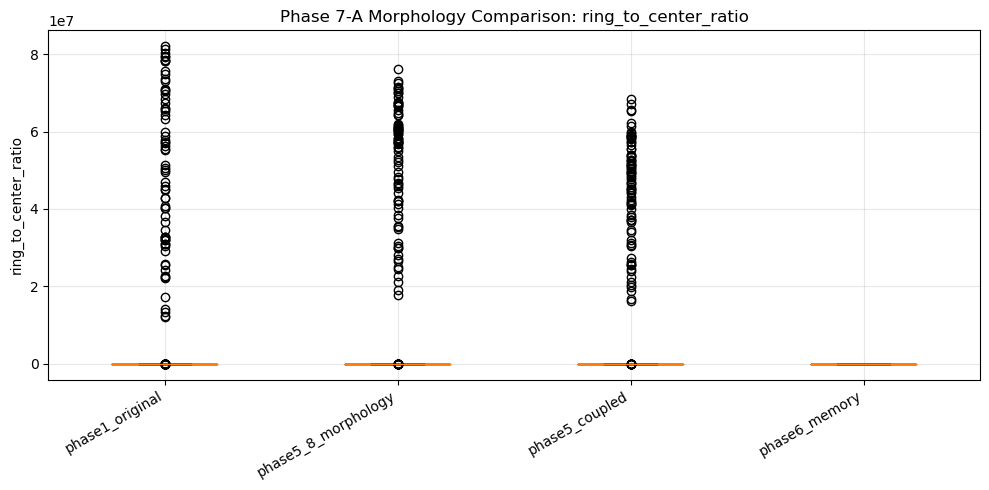

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/figures/morphology_boxplot_ring_to_center_ratio.png


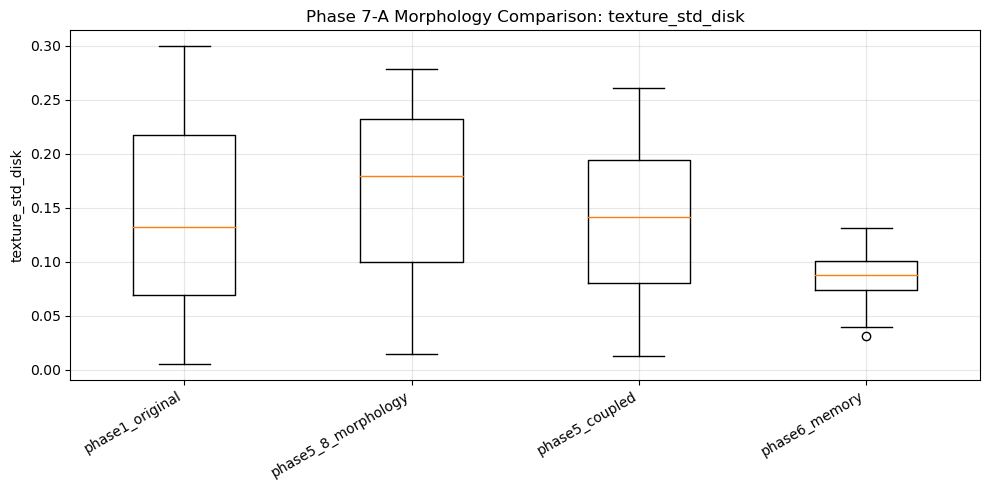

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/figures/morphology_boxplot_texture_std_disk.png


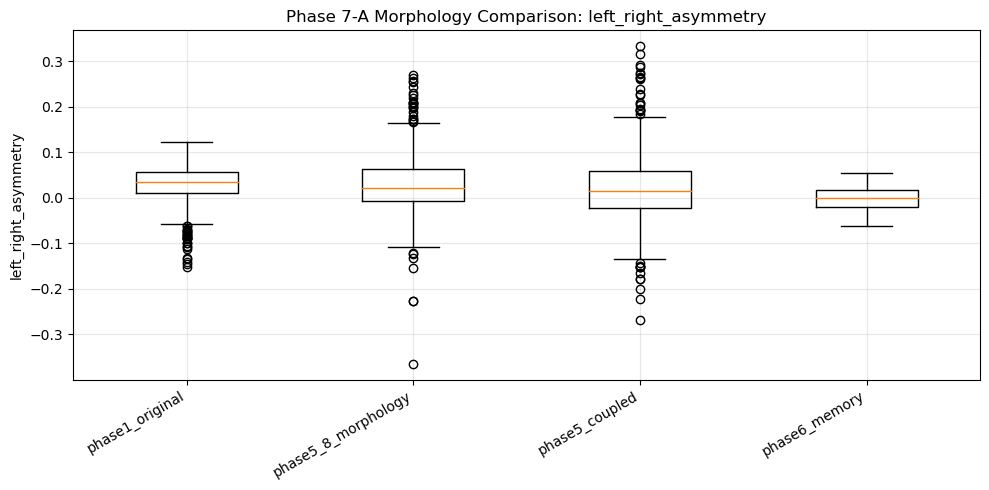

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/figures/morphology_boxplot_left_right_asymmetry.png


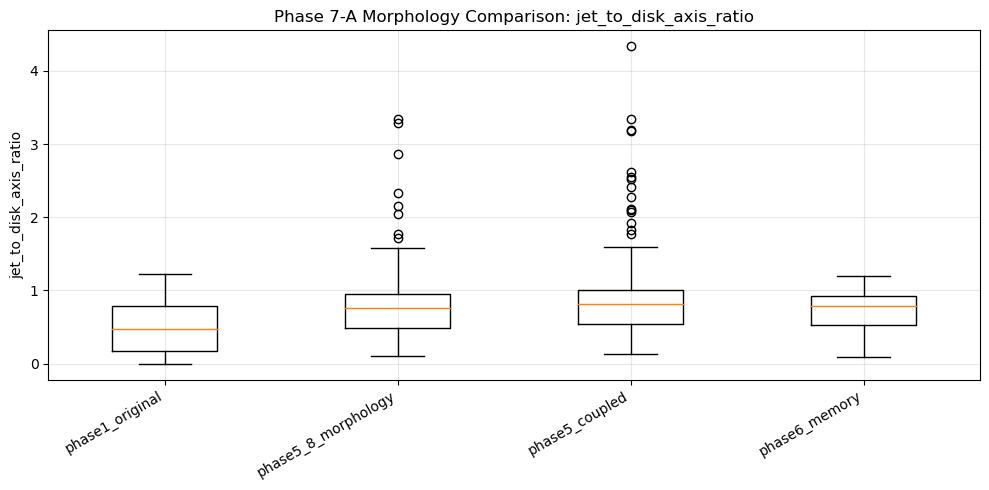

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/figures/morphology_boxplot_jet_to_disk_axis_ratio.png


In [11]:
# ================================================================
# 9. Morphology feature comparison
# ================================================================

morph_feature_cols = [
    "mean_brightness",
    "std_brightness",
    "p95_brightness",
    "center_mean",
    "ring_mean",
    "disk_mean",
    "ring_to_center_ratio",
    "ring_to_outer_ratio",
    "texture_std_disk",
    "centroid_x",
    "centroid_y",
    "radial_mean",
    "radial_std",
    "left_right_asymmetry",
    "upper_lower_asymmetry",
    "jet_axis_mean",
    "disk_axis_mean",
    "jet_to_disk_axis_ratio",
]

summary_rows = []

for dataset_name, sub in morphology_df.groupby("dataset_name"):
    row = {
        "dataset_name": dataset_name,
        "domain": sub["domain"].iloc[0],
        "n": len(sub),
    }
    for col in morph_feature_cols:
        if col in sub.columns:
            row[f"{col}_mean"] = float(sub[col].mean())
            row[f"{col}_std"] = float(sub[col].std())
    summary_rows.append(row)

morph_summary_df = pd.DataFrame(summary_rows)
display(morph_summary_df)

morph_summary_path = save_dataframe(morph_summary_df, "phase7A_morphology_summary_by_dataset")
print("Saved:", morph_summary_path)

# Plot selected interpretable features
selected_features = [
    "ring_to_center_ratio",
    "texture_std_disk",
    "left_right_asymmetry",
    "jet_to_disk_axis_ratio",
]

for feat in selected_features:
    if feat not in morphology_df.columns:
        continue

    plt.figure(figsize=(10, 5))
    labels = []
    data = []

    for name, sub in morphology_df.groupby("dataset_name"):
        vals = sub[feat].dropna().to_numpy(dtype=float)
        if len(vals):
            labels.append(name)
            data.append(vals)

    if data:
        plt.boxplot(data, labels=labels)
        plt.xticks(rotation=30, ha="right")
        plt.ylabel(feat)
        plt.title(f"Phase 7-A Morphology Comparison: {feat}")
        plt.grid(alpha=0.3)
        path = save_plot(PHASE7A_FIG_DIR / f"morphology_boxplot_{feat}.png")
        print("Saved:", path)

## Latent-space consistency

This section uses a trained U-Net encoder, if available, to compare real/external images to synthetic images in learned feature space.

If no checkpoint is available, the notebook skips latent analysis and still keeps the morphology-space analysis.

In [12]:
# ================================================================
# 10. Recreate U-Net encoder and resolve checkpoint
# ================================================================

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class SmallUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.enc4 = DoubleConv(base * 4, base * 8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base * 8, base * 16)
        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)
        self.out = nn.Conv2d(base, out_channels, kernel_size=1)

    def encode(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        return b

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)
        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return torch.sigmoid(self.out(d1))

resolved_checkpoint = None

for candidate in UNET_CANDIDATES:
    if candidate.exists():
        resolved_checkpoint = candidate
        break

if resolved_checkpoint is None:
    print("No U-Net checkpoint found. Latent encoder analysis will be skipped.")
    print("Checked:")
    for c in UNET_CANDIDATES:
        print(" ", c)
    unet = None
else:
    print("Using U-Net checkpoint:", resolved_checkpoint)
    unet = SmallUNet(in_channels=1, out_channels=1, base=32).to(DEVICE)

    checkpoint = torch.load(resolved_checkpoint, map_location=DEVICE)
    state = checkpoint.get("model_state_dict", checkpoint)

    missing, unexpected = unet.load_state_dict(state, strict=False)
    print("Missing keys:", len(missing))
    print("Unexpected keys:", len(unexpected))

    unet.eval()
    for p in unet.parameters():
        p.requires_grad = False

Using U-Net checkpoint: /home/marwa/files/phase1_blackhole_generator/outputs/best_unet_memory_preserving_phase57.pt
Missing keys: 0
Unexpected keys: 0


In [13]:
# ================================================================
# 11. Dataset and feature extraction
# ================================================================

class IndexedImageDataset(Dataset):
    def __init__(self, index_df, real_preprocess=False):
        self.index_df = index_df.reset_index(drop=True).copy()
        self.real_preprocess = real_preprocess

    def __len__(self):
        return len(self.index_df)

    def __getitem__(self, idx):
        row = self.index_df.iloc[idx]
        is_real = row["domain"] != "synthetic"
        arr = load_image01(
            row["image_path"],
            size=IMAGE_SIZE,
            crop_to_square=True,
            normalize_percentiles=REAL_IMAGE_NORMALIZE_PERCENTILES if is_real else None,
        )

        if is_real and REAL_IMAGE_INVERT_IF_DARK_RING:
            arr = 1.0 - arr

        tensor = torch.from_numpy(arr).unsqueeze(0).float()

        return tensor, idx

@torch.no_grad()
def extract_unet_features(index_df):
    if unet is None:
        return None

    ds = IndexedImageDataset(index_df)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    feature_rows = []
    features_all = []

    for batch, idxs in loader:
        batch = batch.to(DEVICE, non_blocking=True)
        feat = unet.encode(batch)
        pooled = F.adaptive_avg_pool2d(feat, (1, 1)).flatten(1)
        pooled_np = pooled.cpu().numpy()

        features_all.append(pooled_np)

        for local_i, idx in enumerate(idxs.numpy()):
            row = index_df.iloc[int(idx)]
            feature_rows.append({
                "domain": row["domain"],
                "dataset_name": row["dataset_name"],
                "sample_id": row["sample_id"],
                "image_path": row["image_path"],
            })

    features = np.concatenate(features_all, axis=0)
    meta_df = pd.DataFrame(feature_rows)

    feature_df = meta_df.copy()
    for j in range(features.shape[1]):
        feature_df[f"latent_{j:03d}"] = features[:, j]

    return feature_df

combined_index_df = pd.concat([synthetic_index_df, real_index_df], ignore_index=True)

if unet is not None and len(combined_index_df):
    latent_df = extract_unet_features(combined_index_df)
    display(latent_df.head())
    latent_path = save_dataframe(latent_df, "phase7A_unet_latent_features")
    print("Saved:", latent_path)
else:
    latent_df = pd.DataFrame()
    print("Latent feature extraction skipped.")

/tmp/ipykernel_31025/889997726.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df[f"latent_{j:03d}"] = features[:, j]
/tmp/ipykernel_31025/889997726.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df[f"latent_{j:03d}"] = features[:, j]
/tmp/ipykernel_31025/889997726.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragm

,domain,dataset_name,sample_id,image_path,latent_000,latent_001,latent_002,latent_003,latent_004,latent_005,...,latent_502,latent_503,latent_504,latent_505,latent_506,latent_507,latent_508,latent_509,latent_510,latent_511
0,synthetic,phase1_original,bh_0001,/home/marwa/files/phase1_blackhole_generator/d...,0.163235,0.140495,0.142620,0.115183,0.096775,0.070723,...,0.207314,0.238495,0.154265,0.127024,0.140419,0.817555,0.091099,0.133096,0.185263,0.143117
1,synthetic,phase1_original,bh_0002,/home/marwa/files/phase1_blackhole_generator/d...,0.197946,0.161733,0.257483,0.179476,0.118377,0.051779,...,0.272737,0.167731,0.221779,0.426725,0.180336,0.423140,0.272845,0.160211,0.155034,0.176013
2,synthetic,phase1_original,bh_0003,/home/marwa/files/phase1_blackhole_generator/d...,0.176598,0.127116,0.121840,0.142844,0.091490,0.080931,...,0.207801,0.203604,0.177114,0.166992,0.126178,0.563966,0.147692,0.139350,0.136802,0.162038
3,synthetic,phase1_original,bh_0004,/home/marwa/files/phase1_blackhole_generator/d...,0.157824,0.137755,0.118905,0.131691,0.088493,0.087903,...,0.192769,0.244227,0.147061,0.109200,0.133628,0.647599,0.098561,0.140485,0.162294,0.156118
4,synthetic,phase1_original,bh_0005,/home/marwa/files/phase1_blackhole_generator/d...,0.235374,0.167742,0.123661,0.188059,0.121291,0.087293,...,0.266579,0.261720,0.203962,0.200424,0.166855,0.202052,0.174325,0.184853,0.147981,0.209751


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/tables/phase7A_unet_latent_features.csv


,domain,dataset_name,sample_id,image_path,pc1,pc2,pc3,pc4,pc5,pc6,pc7,pc8,pc9,pc10
0,synthetic,phase1_original,bh_0001,/home/marwa/files/phase1_blackhole_generator/d...,-13.821278,-9.348591,-1.688422,2.918111,2.231282,2.264166,0.330588,-1.857891,-1.881109,-0.498274
1,synthetic,phase1_original,bh_0002,/home/marwa/files/phase1_blackhole_generator/d...,18.292282,16.000040,0.432265,0.694205,-2.420152,-2.992995,-3.209513,-0.847348,-3.739237,-0.235003
2,synthetic,phase1_original,bh_0003,/home/marwa/files/phase1_blackhole_generator/d...,-7.224517,-1.107234,-8.772152,-1.994482,2.838019,1.228698,2.476169,1.641248,-2.037820,-1.273556
3,synthetic,phase1_original,bh_0004,/home/marwa/files/phase1_blackhole_generator/d...,-13.836544,-9.904275,-6.653206,2.732253,3.233752,-0.187686,0.824249,-1.587193,0.458771,-0.817887
4,synthetic,phase1_original,bh_0005,/home/marwa/files/phase1_blackhole_generator/d...,9.062371,-6.704302,-4.898848,-1.092922,1.357319,1.287594,0.635232,2.600932,-0.339985,0.493379


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/tables/phase7A_latent_pca_coordinates.csv
Explained variance ratio: [0.6452617  0.16359013 0.06678534 0.03178488 0.02161274]


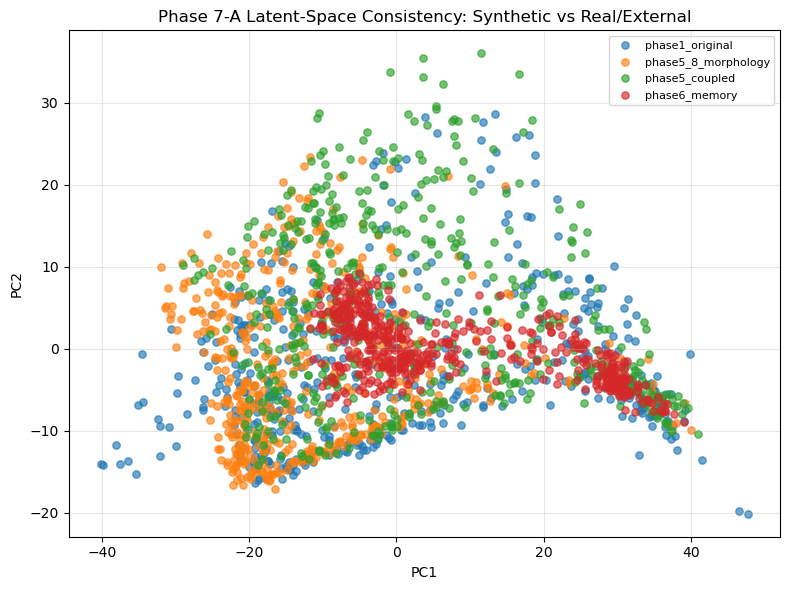

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/figures/latent_pca_synthetic_vs_real.png


In [14]:
# ================================================================
# 12. PCA latent-space comparison
# ================================================================

if len(latent_df) and SKLEARN_AVAILABLE:
    latent_cols = [c for c in latent_df.columns if c.startswith("latent_")]
    X = latent_df[latent_cols].to_numpy(dtype=np.float32)

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    n_components = min(PCA_COMPONENTS, Xs.shape[0], Xs.shape[1])
    pca = PCA(n_components=n_components, random_state=SEED)
    Z = pca.fit_transform(Xs)

    pca_df = latent_df[["domain", "dataset_name", "sample_id", "image_path"]].copy()
    for j in range(n_components):
        pca_df[f"pc{j+1}"] = Z[:, j]

    display(pca_df.head())

    pca_path = save_dataframe(pca_df, "phase7A_latent_pca_coordinates")
    print("Saved:", pca_path)
    print("Explained variance ratio:", pca.explained_variance_ratio_[:5])

    plt.figure(figsize=(8, 6))
    for name, sub in pca_df.groupby("dataset_name"):
        plt.scatter(
            sub["pc1"].to_numpy(dtype=float),
            sub["pc2"].to_numpy(dtype=float),
            alpha=0.65,
            label=name,
            s=28,
        )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Phase 7-A Latent-Space Consistency: Synthetic vs Real/External")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)
    pca_plot_path = save_plot(PHASE7A_FIG_DIR / "latent_pca_synthetic_vs_real.png")
    print("Saved:", pca_plot_path)

else:
    pca_df = pd.DataFrame()
    print("PCA latent-space analysis skipped.")

,domain,dataset_name,sample_id,image_path,morph_pc1,morph_pc2,morph_pc3,morph_pc4,morph_pc5
0,synthetic,phase1_original,bh_0001,/home/marwa/files/phase1_blackhole_generator/d...,-0.460216,2.312505,-0.047785,3.546398,-0.661059
1,synthetic,phase1_original,bh_0002,/home/marwa/files/phase1_blackhole_generator/d...,0.652867,-0.402470,1.200452,-0.094404,-2.434789
2,synthetic,phase1_original,bh_0003,/home/marwa/files/phase1_blackhole_generator/d...,-1.655201,0.361211,0.654316,-0.049451,-1.709998
3,synthetic,phase1_original,bh_0004,/home/marwa/files/phase1_blackhole_generator/d...,-1.181639,1.496715,-1.059861,2.424237,-0.137458
4,synthetic,phase1_original,bh_0005,/home/marwa/files/phase1_blackhole_generator/d...,-4.370862,0.685781,-0.485020,1.395873,-0.397605


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/tables/phase7A_morphology_pca_coordinates.csv


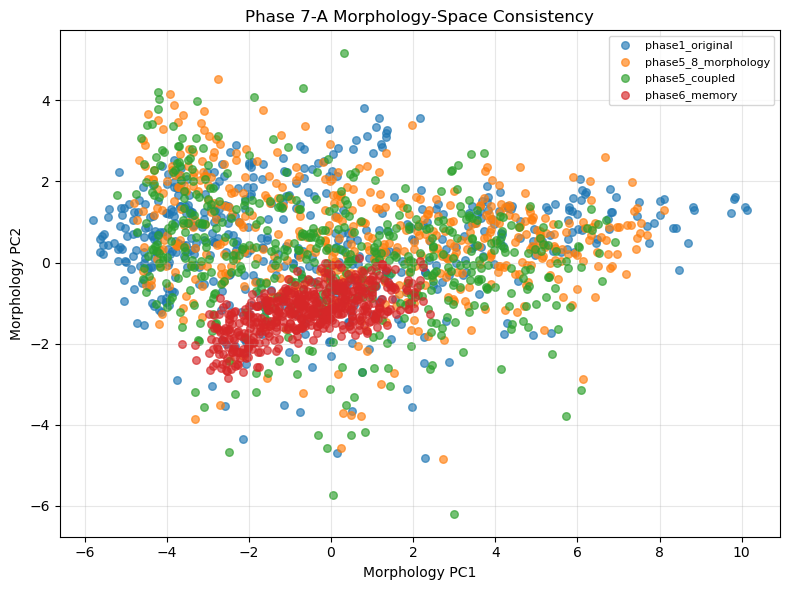

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/figures/morphology_pca_synthetic_vs_real.png


In [15]:
# ================================================================
# 13. Morphology PCA comparison
# ================================================================

if SKLEARN_AVAILABLE and len(morphology_df):
    available_features = [c for c in morph_feature_cols if c in morphology_df.columns]
    morph_clean = morphology_df.dropna(subset=available_features).copy()

    if len(morph_clean) >= 3:
        X = morph_clean[available_features].to_numpy(dtype=np.float32)
        scaler_m = StandardScaler()
        Xs = scaler_m.fit_transform(X)

        n_components = min(5, Xs.shape[0], Xs.shape[1])
        pca_m = PCA(n_components=n_components, random_state=SEED)
        Zm = pca_m.fit_transform(Xs)

        morph_pca_df = morph_clean[["domain", "dataset_name", "sample_id", "image_path"]].copy()
        for j in range(n_components):
            morph_pca_df[f"morph_pc{j+1}"] = Zm[:, j]

        display(morph_pca_df.head())

        morph_pca_path = save_dataframe(morph_pca_df, "phase7A_morphology_pca_coordinates")
        print("Saved:", morph_pca_path)

        plt.figure(figsize=(8, 6))
        for name, sub in morph_pca_df.groupby("dataset_name"):
            plt.scatter(
                sub["morph_pc1"].to_numpy(dtype=float),
                sub["morph_pc2"].to_numpy(dtype=float),
                alpha=0.65,
                label=name,
                s=30,
            )
        plt.xlabel("Morphology PC1")
        plt.ylabel("Morphology PC2")
        plt.title("Phase 7-A Morphology-Space Consistency")
        plt.grid(alpha=0.3)
        plt.legend(fontsize=8)
        morph_pca_plot_path = save_plot(PHASE7A_FIG_DIR / "morphology_pca_synthetic_vs_real.png")
        print("Saved:", morph_pca_plot_path)
    else:
        morph_pca_df = pd.DataFrame()
        print("Not enough complete morphology rows for PCA.")
else:
    morph_pca_df = pd.DataFrame()
    print("Morphology PCA skipped.")

## Nearest synthetic analogues

This section finds the closest synthetic samples for every real/external image.

The point is not to claim the synthetic analogue is physically correct.

The point is to ask:

> Which synthetic morphology/event-family is the real observation closest to?

In [16]:
# ================================================================
# 14. Nearest synthetic analogues in morphology space
# ================================================================

nearest_morph_rows = []

if len(real_morph_df) and SKLEARN_AVAILABLE:
    available_features = [c for c in morph_feature_cols if c in synthetic_morph_df.columns and c in real_morph_df.columns]

    synth_valid = synthetic_morph_df.dropna(subset=available_features).copy()
    real_valid = real_morph_df.dropna(subset=available_features).copy()

    if len(synth_valid) and len(real_valid):
        scaler = StandardScaler()
        Xs = scaler.fit_transform(synth_valid[available_features].to_numpy(dtype=np.float32))
        Xr = scaler.transform(real_valid[available_features].to_numpy(dtype=np.float32))

        nn_model = NearestNeighbors(n_neighbors=min(N_NEIGHBORS, len(synth_valid)), metric="euclidean")
        nn_model.fit(Xs)
        distances, indices = nn_model.kneighbors(Xr)

        for i, (_, real_row) in enumerate(real_valid.iterrows()):
            for rank, synth_idx in enumerate(indices[i]):
                synth_row = synth_valid.iloc[int(synth_idx)]
                nearest_morph_rows.append({
                    "real_sample_id": real_row["sample_id"],
                    "real_image_path": real_row["image_path"],
                    "rank": rank + 1,
                    "synthetic_dataset": synth_row["dataset_name"],
                    "synthetic_sample_id": synth_row["sample_id"],
                    "synthetic_image_path": synth_row["image_path"],
                    "distance": float(distances[i, rank]),
                    "space": "morphology",
                })

nearest_morph_df = pd.DataFrame(nearest_morph_rows)

if len(nearest_morph_df):
    display(nearest_morph_df.head(20))
else:
    print("No morphology nearest-neighbor results. Add real images or check feature completeness.")

nearest_morph_path = save_dataframe(nearest_morph_df, "phase7A_nearest_synthetic_morphology")
print("Saved:", nearest_morph_path)

No morphology nearest-neighbor results. Add real images or check feature completeness.
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/tables/phase7A_nearest_synthetic_morphology.csv


In [17]:
# ================================================================
# 15. Nearest synthetic analogues in latent space
# ================================================================

nearest_latent_rows = []

if len(latent_df) and len(real_index_df) and SKLEARN_AVAILABLE:
    latent_cols = [c for c in latent_df.columns if c.startswith("latent_")]

    synth_latent = latent_df[latent_df["domain"] == "synthetic"].copy()
    real_latent = latent_df[latent_df["domain"] != "synthetic"].copy()

    if len(synth_latent) and len(real_latent):
        scaler = StandardScaler()
        Xs = scaler.fit_transform(synth_latent[latent_cols].to_numpy(dtype=np.float32))
        Xr = scaler.transform(real_latent[latent_cols].to_numpy(dtype=np.float32))

        nn_model = NearestNeighbors(n_neighbors=min(N_NEIGHBORS, len(synth_latent)), metric="euclidean")
        nn_model.fit(Xs)
        distances, indices = nn_model.kneighbors(Xr)

        for i, (_, real_row) in enumerate(real_latent.iterrows()):
            for rank, synth_idx in enumerate(indices[i]):
                synth_row = synth_latent.iloc[int(synth_idx)]
                nearest_latent_rows.append({
                    "real_sample_id": real_row["sample_id"],
                    "real_image_path": real_row["image_path"],
                    "rank": rank + 1,
                    "synthetic_dataset": synth_row["dataset_name"],
                    "synthetic_sample_id": synth_row["sample_id"],
                    "synthetic_image_path": synth_row["image_path"],
                    "distance": float(distances[i, rank]),
                    "space": "unet_latent",
                })

nearest_latent_df = pd.DataFrame(nearest_latent_rows)

if len(nearest_latent_df):
    display(nearest_latent_df.head(20))
else:
    print("No latent nearest-neighbor results. Add real images or provide a U-Net checkpoint.")

nearest_latent_path = save_dataframe(nearest_latent_df, "phase7A_nearest_synthetic_latent")
print("Saved:", nearest_latent_path)

No latent nearest-neighbor results. Add real images or provide a U-Net checkpoint.
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/tables/phase7A_nearest_synthetic_latent.csv


In [18]:
# ================================================================
# 16. Visualize nearest synthetic analogues
# ================================================================

def visualize_nearest_neighbors(nearest_df, title, output_name, max_real=6):
    if nearest_df is None or len(nearest_df) == 0:
        print(f"No nearest-neighbor results for: {title}")
        return None

    unique_real = nearest_df["real_sample_id"].unique()[:max_real]
    k = min(N_NEIGHBORS, nearest_df["rank"].max())

    rows = len(unique_real)
    cols = k + 1

    fig, axes = plt.subplots(rows, cols, figsize=(2.5 * cols, 2.7 * rows), squeeze=False)

    for r, real_id in enumerate(unique_real):
        sub = nearest_df[nearest_df["real_sample_id"] == real_id].sort_values("rank").head(k)
        real_path = sub.iloc[0]["real_image_path"]

        real_img = load_image01(
            real_path,
            size=IMAGE_SIZE,
            crop_to_square=True,
            normalize_percentiles=REAL_IMAGE_NORMALIZE_PERCENTILES,
        )

        axes[r, 0].imshow(real_img, cmap="inferno", vmin=0, vmax=1)
        axes[r, 0].set_title(f"REAL\n{real_id}", fontsize=8)
        axes[r, 0].axis("off")

        for c, (_, row) in enumerate(sub.iterrows(), start=1):
            synth_img = load_image01(row["synthetic_image_path"], size=IMAGE_SIZE, crop_to_square=True)
            axes[r, c].imshow(synth_img, cmap="inferno", vmin=0, vmax=1)
            axes[r, c].set_title(
                f"#{int(row['rank'])} {row['synthetic_dataset']}\n{row['synthetic_sample_id']}\nd={row['distance']:.2f}",
                fontsize=7,
            )
            axes[r, c].axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    path = save_plot(PHASE7A_FIG_DIR / output_name)
    print("Saved:", path)
    return path

visualize_nearest_neighbors(
    nearest_morph_df,
    "Nearest Synthetic Analogues in Morphology Space",
    "nearest_synthetic_analogues_morphology.png",
)

visualize_nearest_neighbors(
    nearest_latent_df,
    "Nearest Synthetic Analogues in U-Net Latent Space",
    "nearest_synthetic_analogues_latent.png",
)

No nearest-neighbor results for: Nearest Synthetic Analogues in Morphology Space
No nearest-neighbor results for: Nearest Synthetic Analogues in U-Net Latent Space


In [19]:
# ================================================================
# 17. Domain distance summary
# ================================================================

distance_rows = []

if len(real_morph_df) and SKLEARN_AVAILABLE:
    available_features = [c for c in morph_feature_cols if c in morphology_df.columns]
    morph_valid = morphology_df.dropna(subset=available_features).copy()

    real_valid = morph_valid[morph_valid["domain"] != "synthetic"].copy()
    synth_valid = morph_valid[morph_valid["domain"] == "synthetic"].copy()

    if len(real_valid) and len(synth_valid):
        scaler = StandardScaler()
        X_all = scaler.fit_transform(morph_valid[available_features].to_numpy(dtype=np.float32))
        morph_valid_scaled = morph_valid[["domain", "dataset_name", "sample_id"]].copy()

        for i, col in enumerate(available_features):
            morph_valid_scaled[col] = X_all[:, i]

        real_scaled = morph_valid_scaled[morph_valid_scaled["domain"] != "synthetic"]
        synth_scaled = morph_valid_scaled[morph_valid_scaled["domain"] == "synthetic"]

        X_real = real_scaled[available_features].to_numpy(dtype=np.float32)

        for dataset_name, sub in synth_scaled.groupby("dataset_name"):
            X_synth = sub[available_features].to_numpy(dtype=np.float32)
            d = pairwise_distances(X_real, X_synth, metric="euclidean")
            distance_rows.append({
                "space": "morphology",
                "synthetic_dataset": dataset_name,
                "mean_min_distance_real_to_synthetic": float(d.min(axis=1).mean()),
                "median_min_distance_real_to_synthetic": float(np.median(d.min(axis=1))),
                "mean_pairwise_distance": float(d.mean()),
                "n_real": len(X_real),
                "n_synthetic": len(X_synth),
            })

if len(latent_df) and len(real_index_df) and SKLEARN_AVAILABLE:
    latent_cols = [c for c in latent_df.columns if c.startswith("latent_")]
    synth_latent = latent_df[latent_df["domain"] == "synthetic"].copy()
    real_latent = latent_df[latent_df["domain"] != "synthetic"].copy()

    if len(synth_latent) and len(real_latent):
        scaler = StandardScaler()
        X_all = scaler.fit_transform(latent_df[latent_cols].to_numpy(dtype=np.float32))
        scaled = latent_df[["domain", "dataset_name", "sample_id"]].copy()
        for i, col in enumerate(latent_cols):
            scaled[col] = X_all[:, i]

        real_scaled = scaled[scaled["domain"] != "synthetic"]
        synth_scaled = scaled[scaled["domain"] == "synthetic"]

        X_real = real_scaled[latent_cols].to_numpy(dtype=np.float32)

        for dataset_name, sub in synth_scaled.groupby("dataset_name"):
            X_synth = sub[latent_cols].to_numpy(dtype=np.float32)
            d = pairwise_distances(X_real, X_synth, metric="euclidean")
            distance_rows.append({
                "space": "unet_latent",
                "synthetic_dataset": dataset_name,
                "mean_min_distance_real_to_synthetic": float(d.min(axis=1).mean()),
                "median_min_distance_real_to_synthetic": float(np.median(d.min(axis=1))),
                "mean_pairwise_distance": float(d.mean()),
                "n_real": len(X_real),
                "n_synthetic": len(X_synth),
            })

domain_distance_df = pd.DataFrame(distance_rows)

if len(domain_distance_df):
    display(domain_distance_df.sort_values(["space", "mean_min_distance_real_to_synthetic"]))
else:
    print("Domain distance summary unavailable. Add real images and/or latent features.")

domain_distance_path = save_dataframe(domain_distance_df, "phase7A_domain_distance_summary")
print("Saved:", domain_distance_path)

Domain distance summary unavailable. Add real images and/or latent features.
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/tables/phase7A_domain_distance_summary.csv


## Final Phase 7-A report

This report is deliberately conservative.

It should not claim that the project predicts real black-hole histories. Instead, it reports whether real/external images are morphologically and latently consistent with the synthetic reference universe.

In [20]:
# ================================================================
# 18. Generate Phase 7-A thesis-style summary
# ================================================================

def df_to_text(df, max_rows=20):
    if df is None or len(df) == 0:
        return "No data available."
    return df.head(max_rows).to_string(index=False)

real_count = len(real_index_df)
synthetic_count = len(synthetic_index_df)
checkpoint_text = str(resolved_checkpoint) if resolved_checkpoint is not None else "No U-Net checkpoint found"

if len(domain_distance_df):
    best_morph = domain_distance_df[domain_distance_df["space"] == "morphology"].sort_values("mean_min_distance_real_to_synthetic").head(1)
    best_latent = domain_distance_df[domain_distance_df["space"] == "unet_latent"].sort_values("mean_min_distance_real_to_synthetic").head(1)
else:
    best_morph = pd.DataFrame()
    best_latent = pd.DataFrame()

phase7a_summary = f'''
# Phase 7-A Summary — Real Observation Consistency Study

## Purpose

Phase 7-A bridges the synthetic black-hole memory experiments with real or externally supplied black-hole observation images.

The goal is not to predict unknown real accretion histories. Real black-hole event histories are not available as supervised labels.

Instead, this phase asks whether real or external observations are consistent with the synthetic morphology and latent-feature spaces created in the earlier phases.

## Data audit

Synthetic reference images indexed: {synthetic_count}

Real/external observation images indexed: {real_count}

Real observation folder:

{REAL_OBS_DIR}

U-Net encoder checkpoint:

{checkpoint_text}

## Morphology-space analysis

The notebook computed interpretable morphology statistics, including ring-to-center contrast, disk texture, centroid displacement, left-right asymmetry, and jet-axis brightness ratios.

Dataset-level morphology summary:

{df_to_text(morph_summary_df, max_rows=12)}

## Latent-space analysis

If a trained U-Net encoder was available, the notebook extracted bottleneck features and projected them using PCA.

This latent-space comparison tests whether real or external images occupy similar feature regions to the synthetic datasets.

## Nearest synthetic analogues

The notebook found nearest synthetic analogues for each real/external observation in morphology space and, when available, U-Net latent space.

Morphology nearest-neighbor preview:

{df_to_text(nearest_morph_df, max_rows=15)}

Latent nearest-neighbor preview:

{df_to_text(nearest_latent_df, max_rows=15)}

## Domain distance summary

{df_to_text(domain_distance_df, max_rows=20)}

## Interpretation

If real/external observations cluster near the synthetic datasets, this suggests that the synthetic renderer captures at least some observation-level morphology found in real images.

If real/external observations lie far outside the synthetic domain, then the synthetic generator must be treated as a controlled proof-of-concept rather than a realistic observational surrogate.

The key scientific distinction is:

- Synthetic phases test whether memory recovery is possible under known controlled conditions.
- Phase 7-A tests whether the synthetic morphology resembles real/external observations enough to motivate cautious transfer analysis.

## Recommended next step

If the real/external observations are close to any synthetic dataset in morphology or latent space, the next phase should perform domain adaptation or synthetic-to-real calibration.

If they are not close, the next step should improve the synthetic renderer or use GRMHD-generated public simulations before attempting any real-data inference.
'''

summary_md_path = PHASE7A_REPORT_DIR / "phase7A_real_observation_consistency_summary.md"
summary_txt_path = PHASE7A_REPORT_DIR / "phase7A_real_observation_consistency_summary.txt"

with open(summary_md_path, "w") as f:
    f.write(phase7a_summary)

with open(summary_txt_path, "w") as f:
    f.write(phase7a_summary)

display(Markdown(phase7a_summary[:4000] + "\n\n..."))

print("Saved:", summary_md_path)
print("Saved:", summary_txt_path)


# Phase 7-A Summary — Real Observation Consistency Study

## Purpose

Phase 7-A bridges the synthetic black-hole memory experiments with real or externally supplied black-hole observation images.

The goal is not to predict unknown real accretion histories. Real black-hole event histories are not available as supervised labels.

Instead, this phase asks whether real or external observations are consistent with the synthetic morphology and latent-feature spaces created in the earlier phases.

## Data audit

Synthetic reference images indexed: 2000

Real/external observation images indexed: 0

Real observation folder:

/home/marwa/files/phase1_blackhole_generator/data/real_observations

U-Net encoder checkpoint:

/home/marwa/files/phase1_blackhole_generator/outputs/best_unet_memory_preserving_phase57.pt

## Morphology-space analysis

The notebook computed interpretable morphology statistics, including ring-to-center contrast, disk texture, centroid displacement, left-right asymmetry, and jet-axis brightness ratios.

Dataset-level morphology summary:

       dataset_name    domain   n  mean_brightness_mean  mean_brightness_std  std_brightness_mean  std_brightness_std  p95_brightness_mean  p95_brightness_std  center_mean_mean  center_mean_std  ring_mean_mean  ring_mean_std  disk_mean_mean  disk_mean_std  ring_to_center_ratio_mean  ring_to_center_ratio_std  ring_to_outer_ratio_mean  ring_to_outer_ratio_std  texture_std_disk_mean  texture_std_disk_std  centroid_x_mean  centroid_x_std  centroid_y_mean  centroid_y_std  radial_mean_mean  radial_mean_std  radial_std_mean  radial_std_std  left_right_asymmetry_mean  left_right_asymmetry_std  upper_lower_asymmetry_mean  upper_lower_asymmetry_std  jet_axis_mean_mean  jet_axis_mean_std  disk_axis_mean_mean  disk_axis_mean_std  jet_to_disk_axis_ratio_mean  jet_to_disk_axis_ratio_std
    phase1_original synthetic 500              0.078781             0.065285             0.150816            0.065736             0.388609            0.258947          0.209115         0.226890        0.355483       0.227226        0.130865       0.124766               6.726235e+06              1.857064e+07              1.053733e+07             1.537815e+07               0.143182              0.083994         0.004800        0.013283         0.013255        0.005367          0.347900         0.107430         0.149332        0.037380                   0.028126                  0.045252                    0.082752                   0.045629            0.109559           0.118160             0.203073            0.134010                     0.478999                    0.327251
phase5_8_morphology synthetic 500              0.094078             0.058298             0.172402            0.047005             0.448063            0.242805          0.217574         0.261205        0.414949       0.201689        0.153504       0.112314               8.566973e+06              2.030713e+07              2.331611e+02             3.624580e+02               0.165894              0.073913         0.003533        0.016773         0.022065        0.012371          0.378439         0.110846         0.176983        0.036040                   0.030900                  0.069883                    0.107729                   0.067350            0.160751           0.109878             0.224561            0.112646                     0.745821                    0.370491
     phase5_coupled synthetic 500              0.082386             0.054008             0.144277            0.046978             0.366083            0.184836          0.181483         0.214320        0.347192       0.178394        0.136293       0.102479               7.416778e+06              1.748644e+07              2.072901e+02             3.005012e+02               0.137655              0.065815         0.002036        0.020441         0.022918        0.014086          0.383228         0.109715         0.177318        0.032692                   0.022886                 

...

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/reports/phase7A_real_observation_consistency_summary.md
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/reports/phase7A_real_observation_consistency_summary.txt


In [21]:
# ================================================================
# 19. Final index
# ================================================================

index = {
    "created_at": datetime.now().isoformat(),
    "project_root": str(PROJECT_ROOT),
    "real_observation_dir": str(REAL_OBS_DIR),
    "phase7A_output_dir": str(PHASE7A_DIR),
    "synthetic_image_mode": SYNTHETIC_IMAGE_MODE,
    "n_synthetic_images": int(len(synthetic_index_df)),
    "n_real_images": int(len(real_index_df)),
    "unet_checkpoint": str(resolved_checkpoint) if resolved_checkpoint is not None else None,
    "main_outputs": {
        "data_audit": str(PHASE7A_TABLE_DIR / "phase7A_data_audit.csv"),
        "synthetic_index": str(PHASE7A_TABLE_DIR / "phase7A_synthetic_image_index.csv"),
        "real_index": str(PHASE7A_TABLE_DIR / "phase7A_real_image_index.csv"),
        "morphology_features": str(PHASE7A_TABLE_DIR / "phase7A_morphology_features.csv"),
        "morphology_summary": str(PHASE7A_TABLE_DIR / "phase7A_morphology_summary_by_dataset.csv"),
        "nearest_synthetic_morphology": str(PHASE7A_TABLE_DIR / "phase7A_nearest_synthetic_morphology.csv"),
        "nearest_synthetic_latent": str(PHASE7A_TABLE_DIR / "phase7A_nearest_synthetic_latent.csv"),
        "domain_distance_summary": str(PHASE7A_TABLE_DIR / "phase7A_domain_distance_summary.csv"),
        "summary_md": str(summary_md_path),
        "summary_txt": str(summary_txt_path),
    }
}

index_path = PHASE7A_DIR / "phase7A_index.json"

with open(index_path, "w") as f:
    json.dump(index, f, indent=2)

print("=" * 80)
print("Phase 7-A complete")
print("=" * 80)
print("Index:", index_path)
print("Output directory:", PHASE7A_DIR)
print("Tables:", PHASE7A_TABLE_DIR)
print("Figures:", PHASE7A_FIG_DIR)
print("Reports:", PHASE7A_REPORT_DIR)
print("=" * 80)

Phase 7-A complete
Index: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/phase7A_index.json
Output directory: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency
Tables: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/tables
Figures: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/figures
Reports: /home/marwa/files/phase1_blackhole_generator/outputs/phase7A_real_observation_consistency/reports
